# Bug Replay simulation
This analysis is about see the effect of bug causing a different value in iob or autosense.

You should download `iobBugInvoke` and `autosensBugInvoke` from xxx, but here's the process of 
creating it from `triodataset`

1. Added glucose trace to feed the simulator, 
   1. Traces are generated by [this notebook](added_glucose.ipynb) 
   2. And this generates the added glucose [this script](Scripts/generate_all_added_glucose.sh)
   3. Added glucose with duration > 24h is [sampled](Scripts/filter_added_glucose.py) and placed into [this folder](iobBugInvoke/sample_added_glucose_trace)
2. initial state where the bugs are triggered
   1. Generated iob states using [this script](Scripts/create_state_from_snap_autosens.py)
   2. Generated autosens states using [this script](Scripts/create_state_from_snap_autosens.py)
   3. each snap shot have their difference and filename noted down [here](autosens-comparison-threshold.json) and [here](iob-comparison-threshold.json). top 100 snap shots are filtered using [this](Scripts/filter_autosens_bugs.py) and [this](Scripts/filter_autosens_bugs.py). (I don't rememeber where the snapshot are comming from?)
3. Run the simulation with [this script](Scripts/run_all_states_all_csvs.sh)

Donwload the date files from xxx, (they should be autosensBugInvoke and iobBugInvoke)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from ParkesErrorGrid.parkes_error import ParkesError

In [2]:
def get_all_glucose(folder: str) -> dict[str, pd.Series]:
    all_glucose: dict[str, list[pd.Series]] = {}

    for file in os.listdir(folder):
        if not file.endswith('.csv'):
            continue
        id = file.split("_")[0]
        stats = pd.read_csv(os.path.join(folder, file))
        all_glucose.setdefault(id, []).append(stats['glucose'])

    return {pid: pd.concat(series, ignore_index=True) for pid, series in all_glucose.items()}


In [3]:
def get_all_glucose_r(root_folder: str, algo: str = 'buggy') -> dict[str, pd.Series]:
    folders = [f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f)) and f.startswith("simOut")]

    by_pid: dict[str, list[pd.Series]] = {}
    for folder in folders:
        folder_path = os.path.join(root_folder, folder, algo)
        for pid, series in get_all_glucose(folder_path).items():
            by_pid.setdefault(pid, []).append(series)

    return {pid: pd.concat(series, ignore_index=True) for pid, series in by_pid.items()}

## Iob bug invocations

In [4]:
buggy_glucose = pd.concat(get_all_glucose_r('iobBugInvoke/', 'buggy').values(), ignore_index=True).tolist()
fixed_glucose = pd.concat(get_all_glucose_r('iobBugInvoke/', 'fixed').values(), ignore_index=True).tolist()

pkeg1 = ParkesError(buggy_glucose, fixed_glucose)
pkeg2 = ParkesError(fixed_glucose, buggy_glucose)

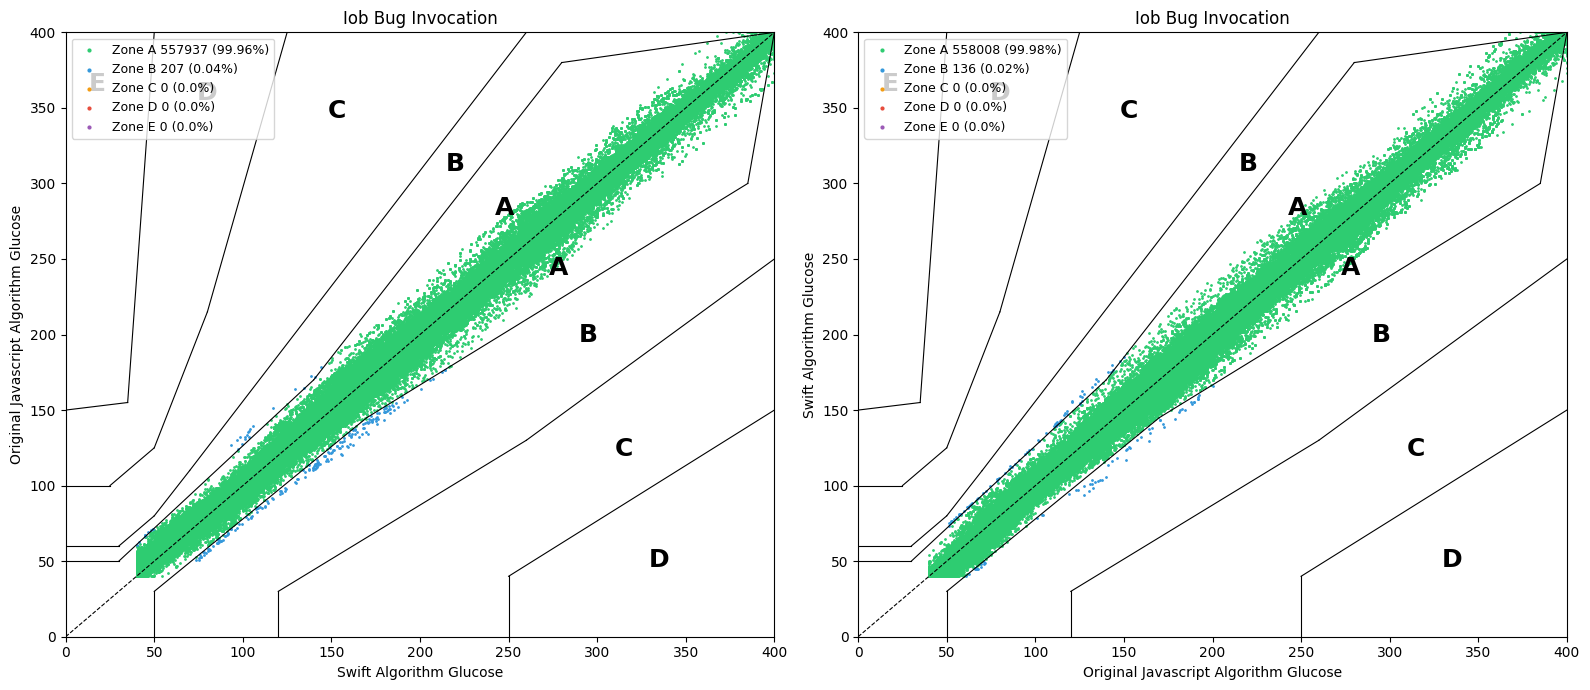

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pkeg1.plot(title="Iob Bug Invocation", x_axis="Original Javascript Algorithm Glucose", y_axis="Swift Algorithm Glucose", size=1, ax=ax2)
pkeg2.plot(title="Iob Bug Invocation", x_axis="Swift Algorithm Glucose", y_axis="Original Javascript Algorithm Glucose", size=1, ax=ax1)

plt.tight_layout()
plt.show()

### Per person

In [6]:
buggy_glucose = get_all_glucose_r('iobBugInvoke/', 'buggy')
fixed_glucose = get_all_glucose_r('iobBugInvoke/', 'fixed')

7 people in both buggy and fixed


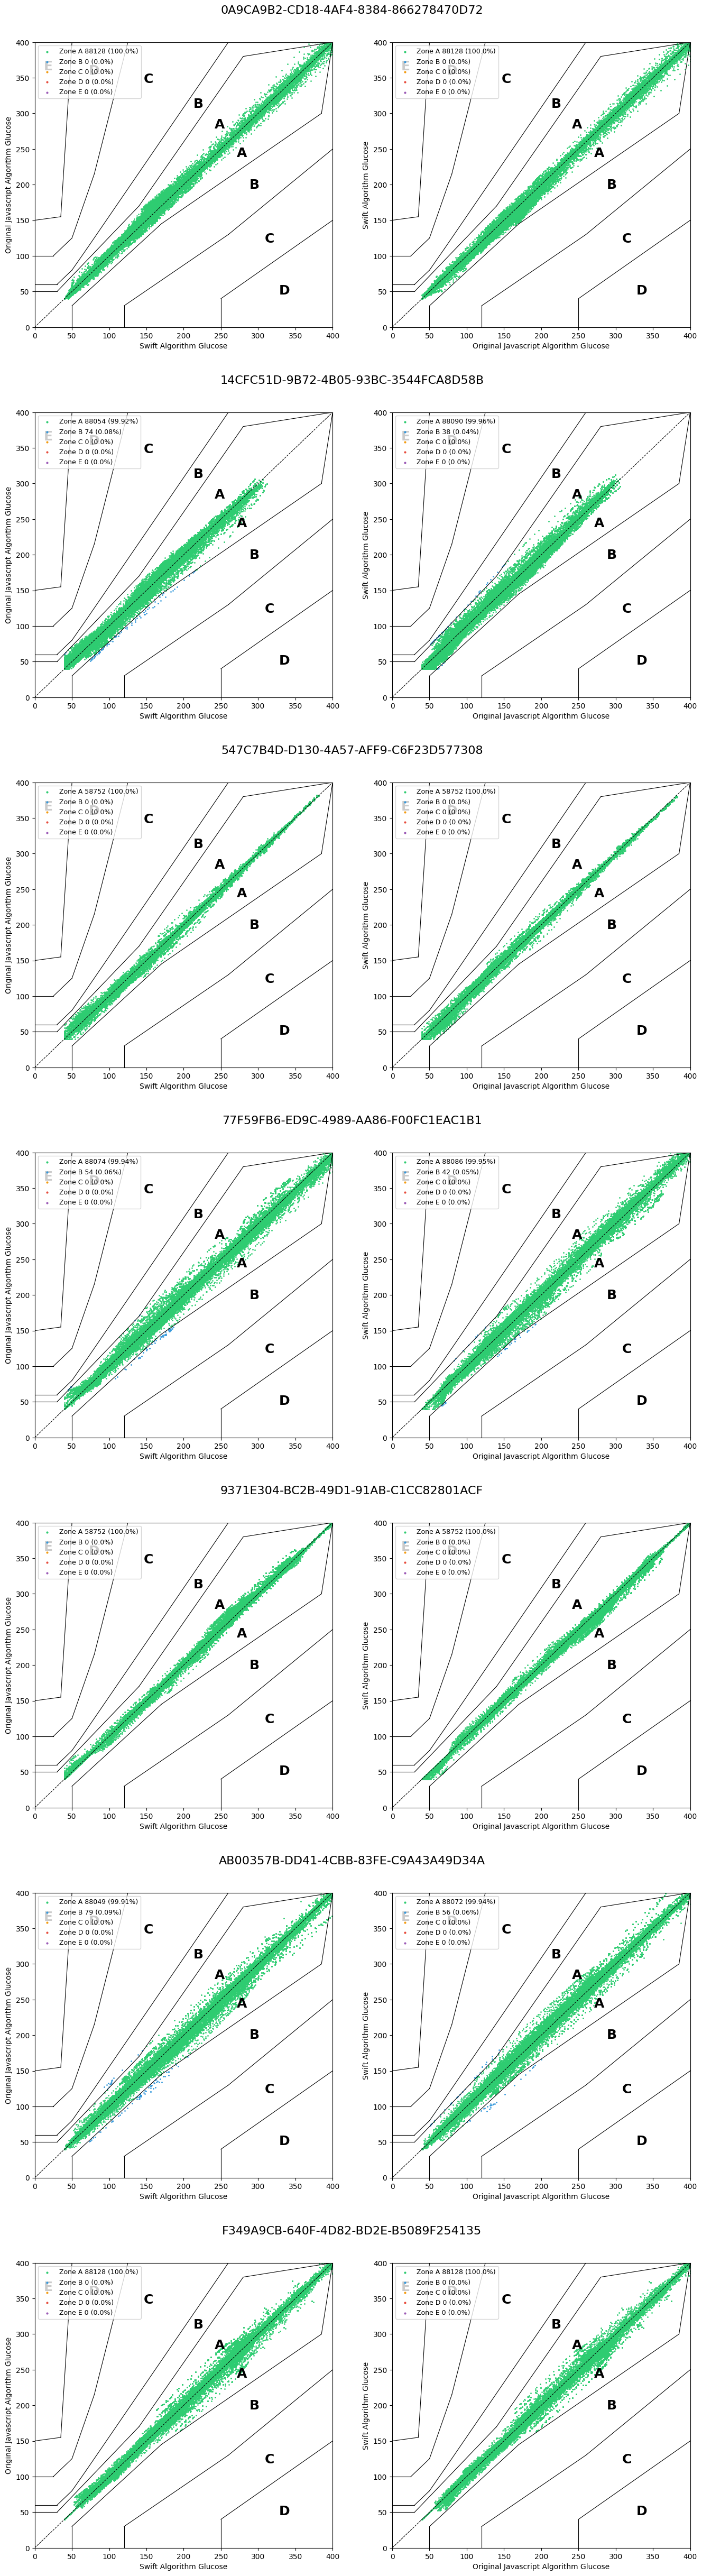

In [10]:
pids = sorted(set(buggy_glucose) & set(fixed_glucose))
print(f"{len(pids)} people in both buggy and fixed")

fig = plt.figure(figsize=(16, 7 * len(pids)))
subfigs = fig.subfigures(len(pids), 1, squeeze=False)[:, 0]

for subfig, pid in zip(subfigs, pids):
    buggy = buggy_glucose[pid].tolist()
    fixed = fixed_glucose[pid].tolist()
    n = min(len(buggy), len(fixed))
    if n < len(buggy) or n < len(fixed):
        print(f"{pid}: length mismatch ({len(buggy)} buggy vs {len(fixed)} fixed), truncating to {n}")
    buggy, fixed = buggy[:n], fixed[:n]

    pkeg1 = ParkesError(buggy, fixed)
    pkeg2 = ParkesError(fixed, buggy)

    subfig.suptitle(pid, fontsize=16)
    ax1, ax2 = subfig.subplots(1, 2)
    pkeg1.plot(title="", x_axis="Original Javascript Algorithm Glucose", y_axis="Swift Algorithm Glucose", size=1, ax=ax2)
    pkeg2.plot(title="", x_axis="Swift Algorithm Glucose", y_axis="Original Javascript Algorithm Glucose", size=1, ax=ax1)

    # subfig.tight_layout()

plt.show()

## Autosens bug invocations

In [7]:
buggy_glucose = get_all_glucose_r('autosensBugInvoke/', 'buggy')
fixed_glucose = get_all_glucose_r('autosensBugInvoke/', 'fixed')

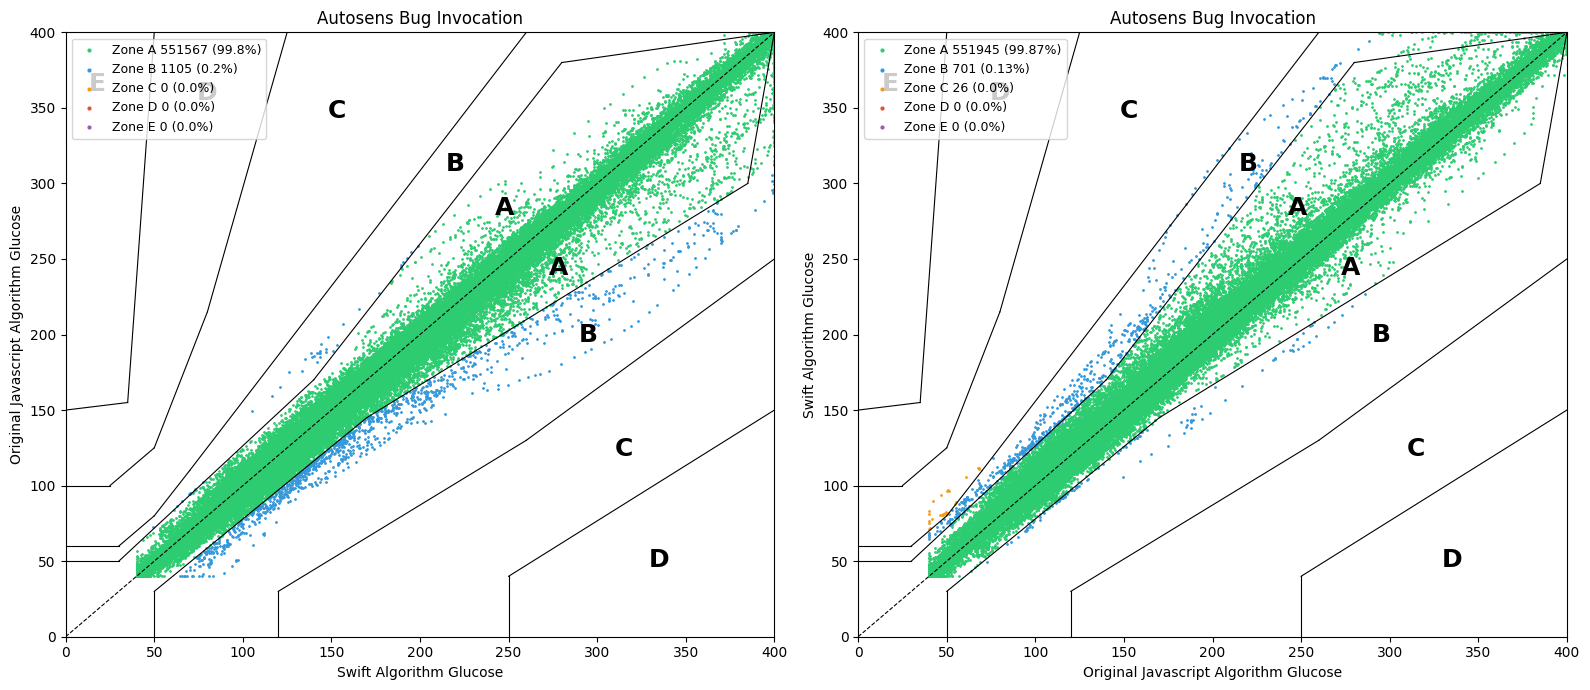

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pkeg1 = ParkesError(buggy_glucose.to_list(), fixed_glucose.to_list())
pkeg2 = ParkesError(fixed_glucose.to_list(), buggy_glucose.to_list())
pkeg1.plot(title="Autosens Bug Invocation", x_axis="Original Javascript Algorithm Glucose", y_axis="Swift Algorithm Glucose", size=1, ax=ax2)
pkeg2.plot(title="Autosens Bug Invocation", x_axis="Swift Algorithm Glucose", y_axis="Original Javascript Algorithm Glucose", size=1, ax=ax1)

plt.tight_layout()
plt.show()

# Case study

## Autosens

Run the [`single_bug_invoke_run_autosens.sh`](Scripts/single_bug_invoke_run_autosens.sh)

## Iob

Run the [`Single_bug_invoke_run_iob.sh`](Scripts/single_bug_invoke_run_iob.sh)

## Visualize with [plot script](Scripts/plot_glucose.py)